In [2]:
%pip install -Uq numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np  

In [4]:
%pip install -Uq pymcel

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pymcel as pc 

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [1]:
%pip install -Uq rebound

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install -Uq pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install -Uq plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install -Uq nbformat

Note: you may need to restart the kernel to use updated packages.


In [ ]:
tabla_sol, jd_sol, X_sol = pc.consulta_horizons(
    id='Sun',
    location ='@SSB',
    epochs = '2026-02-26 00:00:00',
)

X_sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [ ]:
tabla_jup, jd_jup, X_jup = pc.consulta_horizons(
    id='Jupiter Barycenter',
    location='@SSB',
    epochs='2026-02-26 00:00:00',
)

print("Jupiter position (X_jup):")
print(X_jup)

Jupiter position (X_jup):
[-3.13499559e+11  7.16531655e+11  4.04379637e+09 -1.21253772e+04
 -4.61863891e+03  2.90510926e+02]


In [ ]:
r_sol_0 = X_sol[:3]  # Posición del Sol
r_jup_0 = X_jup[:3]  # Posición de Júpiter

v_sol_0 = X_sol[3:]  # Velocidad del Sol
v_jup_0 = X_jup[3:]  # Velocidad de Júpiter

In [ ]:
deltat = 1*86400  # Un día en segundos

r_jup_dt = r_jup_0 + v_jup_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jup_0, r_jup_dt


(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]))

In [ ]:
import numpy as np 

In [ ]:
mu_sol = pc.constantes.mu_sun
mu_jup = pc.constantes.mu_jupiter

rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89040582,  -4635.79206931,    290.41467508])

In [ ]:
#Velocidad del Sol en t+deltat usando la misma aproximación

rij_vec_sol = r_sol_0 - r_jup_0
v_sol_dt = v_sol_0 - mu_jup * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * deltat
v_sol_dt

array([12.2036746 ,  1.25570472, -0.24251222])

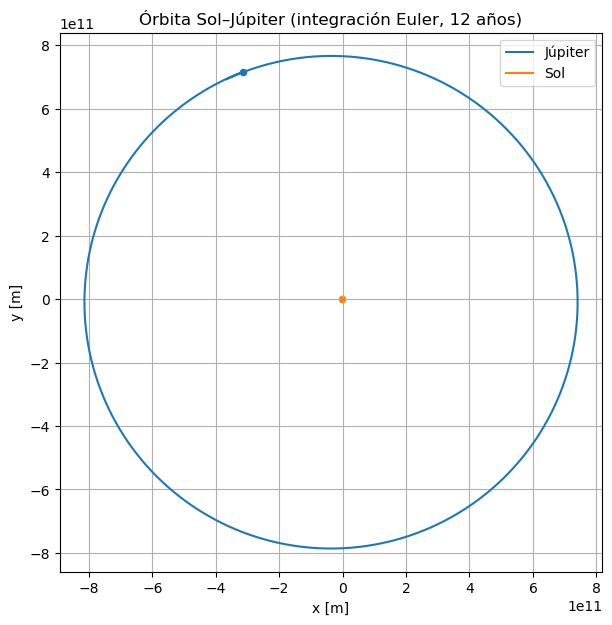

In [ ]:
import matplotlib.pyplot as plt

# Tiempo total: 12 años en segundos (aprox.)
years = 12
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year

# Paso de integración: ya tenemos deltat = 1 día en segundos
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas para guardar la trayectoria
r_jup_hist = []
r_sol_hist = []

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_jup_hist.append(r_jup.copy())
    r_sol_hist.append(r_sol.copy())

    # Vector de separación Júpiter - Sol
    rij = r_jup - r_sol
    r = np.linalg.norm(rij)

    # Aceleraciones mutuas (dos cuerpos)
    a_jup = -mu_sol * rij / r**3
    a_sol =  mu_jup * rij / r**3  # misma dirección, signo contrario y masa diferente

    # Integración tipo Euler (mismo esquema que usaste antes)
    v_jup = v_jup + a_jup * deltat
    r_jup = r_jup + v_jup * deltat

    v_sol = v_sol + a_sol * deltat
    r_sol = r_sol + v_sol * deltat

r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(7, 7))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter", color="tab:blue")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")

# Marcamos posiciones iniciales
plt.scatter(r_jup_0[0], r_jup_0[1], color="tab:blue", s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (integración Euler, 12 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

Método de Leap-Frog para las posiciones del Sol y Júpiter en 12 años 

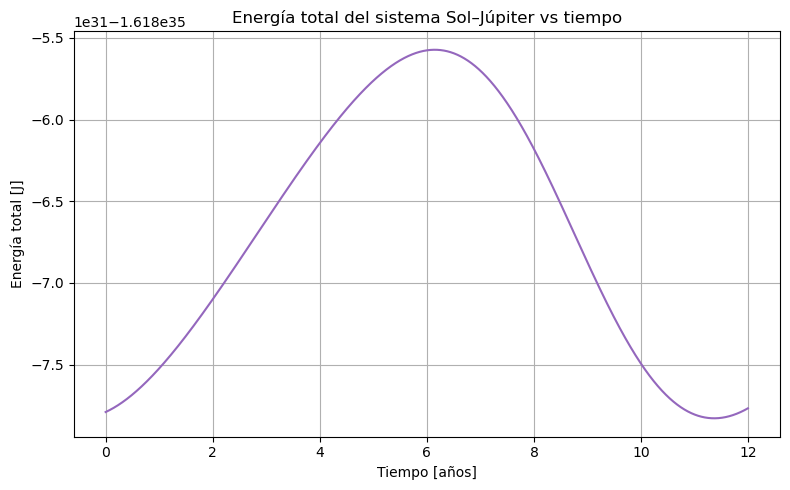

In [ ]:
# Cálculo y gráfico de la energía total (cinética + potencial) en función del tiempo

# Masas a partir de parámetros gravitacionales (mu = G*M)
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_sol = mu_sol / G
M_jup = mu_jup / G

# Tiempo asociado a cada paso (en segundos y en años)
t_array = np.arange(N_steps) * deltat          # s
t_years = t_array / seconds_per_year          # años

# Posición relativa Júpiter–Sol en cada instante
r_rel = r_jup_hist - r_sol_hist               # vector r_jup - r_sol
r_norm = np.linalg.norm(r_rel, axis=1)        # distancia |r|

# Energía potencial gravitatoria (dos cuerpos)
U = -G * M_sol * M_jup / r_norm               # J

# Velocidades relativas aproximadas por diferencias finitas hacia adelante
v_jup_hist = np.diff(r_jup_hist, axis=0) / deltat
v_sol_hist = np.diff(r_sol_hist, axis=0) / deltat

# Igualamos longitud de arrays de energía recortando el último paso en U
U = U[:-1]
t_years_energy = t_years[:-1]

# Energías cinéticas
K_jup = 0.5 * M_jup * np.sum(v_jup_hist**2, axis=1)
K_sol = 0.5 * M_sol * np.sum(v_sol_hist**2, axis=1)

E_total = K_jup + K_sol + U    # energía total

plt.figure(figsize=(8, 5))
plt.plot(t_years_energy, E_total, color="tab:purple")
plt.xlabel("Tiempo [años]")
plt.ylabel("Energía total [J]")
plt.title("Energía total del sistema Sol–Júpiter vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()